# Prediction Layer Demo

This notebook demonstrates the first slice of a prediction layer over `market_data`:
`forecasting/market_data_forecast_view.sql` (a BigQuery view unifying every daily,
price-like asset onto one shape) wired into `AIML-ML-Multi-Forecast-Engine` -- a
separate, already-existing multi-series forecasting engine checked out alongside this
repo (`AIML-ML-Multi-Forecast-Engine/`, its own `uv` project and CLI, not modified by
this work at all).

`market_data`'s BigQuery tables have no real rows yet (schema-only -- see
`market_data_schema_demo.ipynb`), so this notebook generates a **synthetic** sample
locally, shaped exactly like the `forecast_assets` view's output, and runs the real
engine's `smoke` mode against it via `uv run horizons run` -- an actual subprocess call
into that repo's own environment, not a simulation. Every result shown below (the
leaderboard, the diagnostic plots) is produced by a real LightGBM training run on this
notebook's own execution, not a hardcoded example.

Design spec: `docs/superpowers/specs/2026-07-22-forecast-layer-integration-design.md`.
Implementation plan: `docs/superpowers/plans/2026-07-22-forecast-layer-integration.md`.
More detail: `forecasting/README.md`.

Sections:
1. Architecture
2. Generating the synthetic sample
3. The view SQL and the forecast config
4. Running the engine for real
5. Inspecting the real results
6. Known limitation: the item x location grain
7. Running this against real BigQuery data later

In [1]:
import os
import subprocess
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import yaml

pd.set_option("display.max_rows", 40)
pd.set_option("display.width", 160)
%matplotlib inline

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from forecasting.generate_synthetic_sample import generate_synthetic_assets

# AIML-ML-Multi-Forecast-Engine is nested inside the *main* repo checkout, not this
# worktree -- same layout gotcha documented in forecasting/README.md. Absolute path,
# not relative, for the same reason the config file itself uses one.
ENGINE_DIR = Path("D:/MyOffice/AXONS/Macro_data/AIML-ML-Multi-Forecast-Engine")
assert ENGINE_DIR.exists(), f"AIML-ML-Multi-Forecast-Engine not found at {ENGINE_DIR}"
print(f"REPO_ROOT: {REPO_ROOT}")
print(f"ENGINE_DIR: {ENGINE_DIR}")

REPO_ROOT: D:\MyOffice\AXONS\macro_data-market-data-schema
ENGINE_DIR: D:\MyOffice\AXONS\Macro_data\AIML-ML-Multi-Forecast-Engine


## 1. Architecture

Three domain tables in `market_data` (daily price series only -- `ticks`, `holidays`,
and `economic_indicators` are out of scope, see the design spec's non-goals) feed a
single unifying view. The engine treats every asset as one grain (`catalog_id`), with
`domain_table` filling its required second grain dimension.

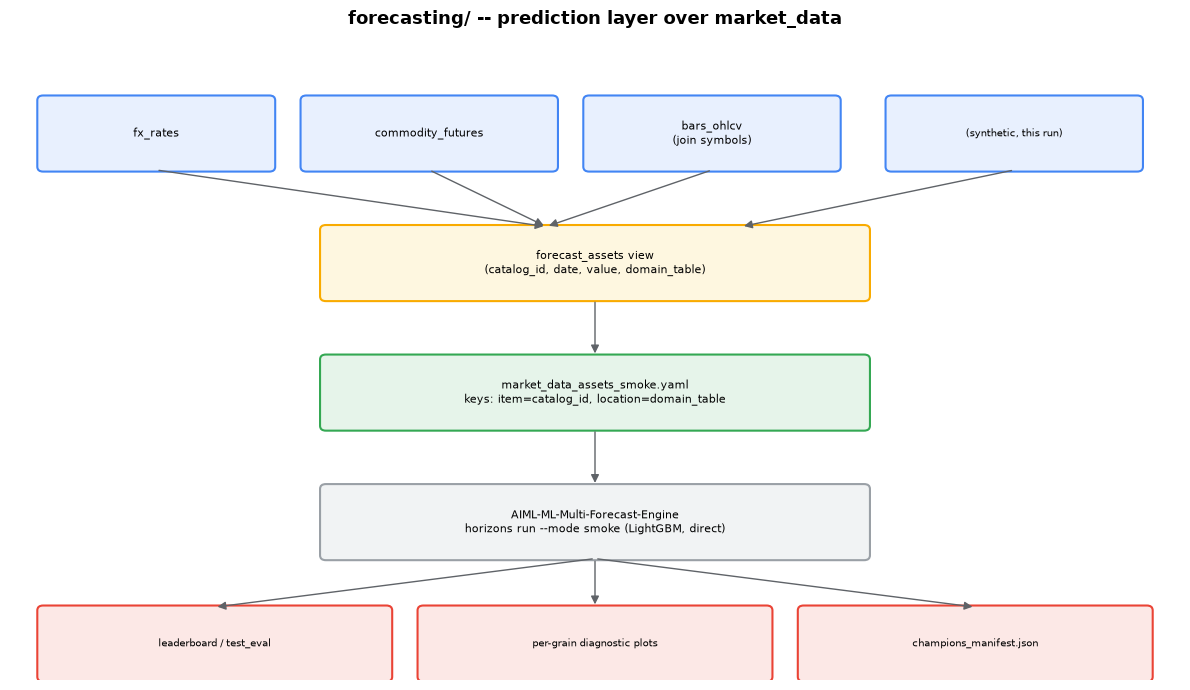

In [2]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

LANE_COLORS = {
    "source": ("#e8f0fe", "#4285f4"),
    "view": ("#fef7e0", "#f9ab00"),
    "config": ("#e6f4ea", "#34a853"),
    "engine": ("#f1f3f4", "#9aa0a6"),
    "output": ("#fce8e6", "#ea4335"),
}


def draw_box(ax, x, y, w, h, text, lane, fontsize=8):
    fc, ec = LANE_COLORS[lane]
    ax.add_patch(
        FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.06", fc=fc, ec=ec, lw=1.5)
    )
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fontsize)


def draw_arrow(ax, start, end):
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=12, color="#5f6368", lw=1.0))


fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 12)
ax.set_ylim(0, 8)
ax.axis("off")
ax.set_title("forecasting/ -- prediction layer over market_data", fontsize=13, fontweight="bold")

draw_box(ax, 0.3, 6.3, 2.4, 0.9, "fx_rates", "source")
draw_box(ax, 3.0, 6.3, 2.6, 0.9, "commodity_futures", "source")
draw_box(ax, 5.9, 6.3, 2.6, 0.9, "bars_ohlcv\n(join symbols)", "source")
draw_box(ax, 9.0, 6.3, 2.6, 0.9, "(synthetic, this run)", "source", fontsize=7.5)

draw_box(ax, 3.2, 4.7, 5.6, 0.9, "forecast_assets view\n(catalog_id, date, value, domain_table)", "view")
for x in (1.5, 4.3, 7.2):
    draw_arrow(ax, (x, 6.3), (5.5, 5.6))
draw_arrow(ax, (10.3, 6.3), (7.5, 5.6))

draw_box(ax, 3.2, 3.1, 5.6, 0.9, "market_data_assets_smoke.yaml\nkeys: item=catalog_id, location=domain_table", "config")
draw_arrow(ax, (6.0, 4.7), (6.0, 4.0))

draw_box(ax, 3.2, 1.5, 5.6, 0.9, "AIML-ML-Multi-Forecast-Engine\nhorizons run --mode smoke (LightGBM, direct)", "engine")
draw_arrow(ax, (6.0, 3.1), (6.0, 2.4))

draw_box(ax, 0.3, 0.0, 3.6, 0.9, "leaderboard / test_eval", "output", fontsize=7.5)
draw_box(ax, 4.2, 0.0, 3.6, 0.9, "per-grain diagnostic plots", "output", fontsize=7.5)
draw_box(ax, 8.1, 0.0, 3.6, 0.9, "champions_manifest.json", "output", fontsize=7.5)
for x in (2.1, 6.0, 9.9):
    draw_arrow(ax, (6.0, 1.5), (x, 0.9))

plt.tight_layout()
plt.show()

## 2. Generating the synthetic sample

`market_data` has no real rows yet (no ingestion pipeline exists -- see the design
spec's non-goals), so `forecasting/generate_synthetic_sample.py` produces a local
random-walk sample shaped exactly like `forecast_assets`'s output: 3 domains x 5
assets = 15 series, written to the exact absolute path the smoke config expects.

In [3]:
df = generate_synthetic_assets()
data_path = REPO_ROOT / "forecasting" / "data" / "synthetic_forecast_assets.parquet"
data_path.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(data_path, index=False)

print(f"{len(df)} rows, {df['catalog_id'].nunique()} assets -> {data_path}")
df.groupby("domain_table")["catalog_id"].nunique()

19485 rows, 15 assets -> D:\MyOffice\AXONS\macro_data-market-data-schema\forecasting\data\synthetic_forecast_assets.parquet


domain_table
bars_ohlcv           5
commodity_futures    5
fx_rates             5
Name: catalog_id, dtype: int64

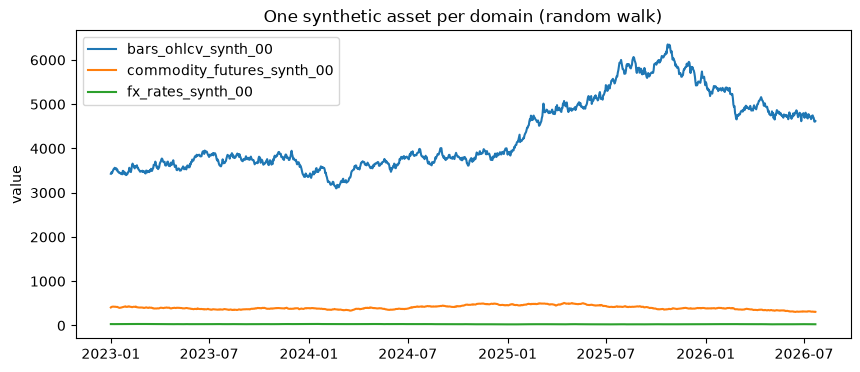

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
for domain, sub in df.groupby("domain_table"):
    one_asset = sub[sub["catalog_id"] == sub["catalog_id"].iloc[0]]
    ax.plot(one_asset["date"], one_asset["value"], label=one_asset["catalog_id"].iloc[0])
ax.set_title("One synthetic asset per domain (random walk)")
ax.set_ylabel("value")
ax.legend()
plt.show()

## 3. The view SQL and the forecast config

Both are static files this notebook reads from disk (not hardcoded copies), same
"parse the real file" approach as `market_data_schema_demo.ipynb`.

In [5]:
view_sql = (REPO_ROOT / "forecasting" / "market_data_forecast_view.sql").read_text(encoding="utf-8")
print(view_sql)

-- forecast_assets: unifies every daily, price-like asset in market_data onto one
-- shape for AIML-ML-Multi-Forecast-Engine. See
-- docs/superpowers/specs/2026-07-22-forecast-layer-integration-design.md.
--
-- Replace `your-gcp-project` with your actual GCP project id, matching
-- market_data_schema.sql. Not applied by any script in this repo -- run by
-- hand (bq query / BigQuery console) once market_data_schema.sql has been
-- applied to a real project.

CREATE VIEW `your-gcp-project.market_data.forecast_assets` AS

SELECT
  catalog_id,
  rate_date AS date,
  rate AS value,
  'fx_rates' AS domain_table
FROM `your-gcp-project.market_data.fx_rates`

UNION ALL

SELECT
  catalog_id,
  trade_date AS date,
  close AS value,
  'commodity_futures' AS domain_table
FROM `your-gcp-project.market_data.commodity_futures`

UNION ALL

SELECT
  s.catalog_id,
  DATE(b.bar_start_ts) AS date,
  b.close AS value,
  'bars_ohlcv' AS domain_table
FROM `your-gcp-project.market_data.bars_ohlcv` AS b
INNER J

In [6]:
config_path = REPO_ROOT / "forecasting" / "configs" / "market_data_assets_smoke.yaml"
config = yaml.safe_load(config_path.read_text(encoding="utf-8"))

print("dataset:", config["dataset"])
print("horizon:", config["horizon"])
print("data_sources.modeling_base:", config["data_sources"]["modeling_base"])
print("models.lightgbm.variants:", config["models"]["lightgbm"]["variants"])

dataset: {'target': 'value', 'date': 'date', 'freq': 'D', 'keys': {'item': 'catalog_id', 'location': 'domain_table'}}
horizon: {'horizons': [1, 7, 30], 'unit': 'days', 'architectures': ['direct']}
data_sources.modeling_base: {'type': 'parquet', 'path': 'D:/MyOffice/AXONS/macro_data-market-data-schema/forecasting/data/synthetic_forecast_assets.parquet'}
models.lightgbm.variants: [{'name': 'lgb_l1'}]


## 4. Running the engine for real

A real subprocess call into `AIML-ML-Multi-Forecast-Engine`'s own environment --
`uv run horizons run --mode smoke`. `PYTHONIOENCODING=utf-8` works around a
Windows-only console encoding crash in the engine's final leaderboard print (the run
itself completes and writes every artifact either way -- see `forecasting/README.md`
for the full explanation); everything up to that point is unaffected.

`MPLBACKEND` also has to be overridden: this notebook's own kernel sets it to
`module://matplotlib_inline.backend_inline` for `%matplotlib inline`, and
`subprocess.run(env=...)` inherits the parent's environment by default -- the child
process's matplotlib install doesn't have `matplotlib_inline` and crashes trying to
honor that backend. `Agg` is a safe headless default for a subprocess with no
display anyway.

In [7]:
env = dict(os.environ)
env["PYTHONIOENCODING"] = "utf-8"
env["MPLBACKEND"] = "Agg"

result = subprocess.run(
    ["uv", "run", "horizons", "run", "--mode", "smoke", "--config", str(config_path)],
    cwd=ENGINE_DIR,
    env=env,
    capture_output=True,
    text=True,
    timeout=300,
)

print(f"exit code: {result.returncode}")
print(result.stdout[-2500:])
if result.returncode != 0:
    print("--- stderr (tail) ---")
    print(result.stderr[-2500:])

assert result.returncode == 0, "smoke run failed -- see stderr above"
print("\nOK: smoke run completed successfully")

exit code: 0
                         erboard.png                                       
                    INFO     Per-horizon line plot saved:                      
                             artifacts\market_data_assets_smoke\_smoke\viz\lead
                             erboard_by_horizon_line.png                       
[07/22/26 21:01:58] INFO     Per-horizon bar plot saved:                       
                             artifacts\market_data_assets_smoke\_smoke\viz\lead
                             erboard_by_horizon_bar.png                        
                    INFO     Test leaderboard plot saved:                      
                             artifacts\market_data_assets_smoke\_smoke\viz\test
                             _leaderboard.png                                  
                    INFO     Test leaderboard by-horizon plot saved:           
                             artifacts\market_data_assets_smoke\_smoke\viz\test
                             _l

## 5. Inspecting the real results

Smoke/experiment mode doesn't write `output.predictions.path` (that's a
production/inference-only artifact) -- the real outputs land under
`artifacts/market_data_assets_smoke/_smoke/` inside the engine's own directory.

In [8]:
artifacts_dir = ENGINE_DIR / "artifacts" / "market_data_assets_smoke" / "_smoke"
assert artifacts_dir.exists(), f"expected artifacts at {artifacts_dir}"

leaderboard = pd.read_parquet(artifacts_dir / "leaderboard.parquet")
leaderboard

,model,rmse,mae,smape,wape,rrmse,rmae,mean_actual,mean_pred,train_time_s,predict_time_s
0,lgb_direct_lgb_l1,673.832607,330.88381,40.613433,0.179067,0.364652,0.179067,1847.666934,1565.205222,0.617667,0.009


In [9]:
test_eval_by_horizon = pd.read_parquet(artifacts_dir / "test_eval_by_horizon.parquet")
test_eval_by_horizon

,model,architecture,horizon,split,rmse,mae,smape,wape,rrmse,rmae,mean_actual,mean_pred
0,lgb_direct_lgb_l1,direct,1,test,676.685039,320.244521,39.531501,0.174177,0.368040,0.174177,1838.619922,1545.226460
1,lgb_direct_lgb_l1,direct,7,test,658.605999,315.646720,40.262199,0.171860,0.358591,0.171860,1836.648353,1564.123273
2,lgb_direct_lgb_l1,direct,30,test,647.545700,318.444188,44.465424,0.174013,0.353850,0.174013,1830.000994,1593.763369


The per-horizon feature cache proves the grain mapping actually flowed through
feature engineering: all 15 synthetic `catalog_id`s, all 3 `domain_table` values, real
lag/rolling/EWMA/calendar features computed per asset.

In [10]:
horizon_cache = pd.read_parquet(artifacts_dir / "_horizon_cache" / "horizon_7.parquet")
print(f"{len(horizon_cache)} rows, {horizon_cache['catalog_id'].nunique()} unique catalog_id, "
      f"domains: {sorted(horizon_cache['domain_table'].unique())}")
feature_cols = [c for c in horizon_cache.columns if c.startswith("value_") or c in ("year", "month_sin", "is_weekend")]
horizon_cache[["catalog_id", "domain_table", "date"] + feature_cols].head(8)

19380 rows, 15 unique catalog_id, domains: ['bars_ohlcv', 'commodity_futures', 'fx_rates']


,catalog_id,domain_table,date,year,month_sin,is_weekend,value_lag_1,value_lag_7,value_lag_14,value_lag_30,value_roll_mean_7,value_roll_mean_30,value_ewma_01
0,bars_ohlcv_synth_00,bars_ohlcv,2023-01-01,2023,0.5,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,bars_ohlcv_synth_00,bars_ohlcv,2023-01-02,2023,0.5,0,3428.255127,NaN,NaN,NaN,3428.255127,3428.255127,3428.255127
2,bars_ohlcv_synth_00,bars_ohlcv,2023-01-03,2023,0.5,0,3458.996582,NaN,NaN,NaN,3443.625977,3443.625977,3431.329346
3,bars_ohlcv_synth_00,bars_ohlcv,2023-01-04,2023,0.5,0,3440.202881,NaN,NaN,NaN,3442.484863,3442.484863,3432.216797
4,bars_ohlcv_synth_00,bars_ohlcv,2023-01-05,2023,0.5,0,3471.349609,NaN,NaN,NaN,3449.701172,3449.701172,3436.129883
5,bars_ohlcv_synth_00,bars_ohlcv,2023-01-06,2023,0.5,0,3507.306152,NaN,NaN,NaN,3461.222168,3461.222168,3443.247559
6,bars_ohlcv_synth_00,bars_ohlcv,2023-01-07,2023,0.5,1,3531.769531,NaN,NaN,NaN,3472.979980,3472.979980,3452.099854
7,bars_ohlcv_synth_00,bars_ohlcv,2023-01-08,2023,0.5,1,3537.214355,3428.255127,NaN,NaN,3482.156250,3482.156250,3460.611328


These are the engine's own diagnostic plots from this run -- `error_by_catalog_id.png`
and `error_by_domain_table.png` are the direct visual confirmation that `item:
catalog_id` / `location: domain_table` were picked up correctly (see Section 6 for why
that mapping is a deliberate, if imperfect, fit).

error_by_catalog_id.png


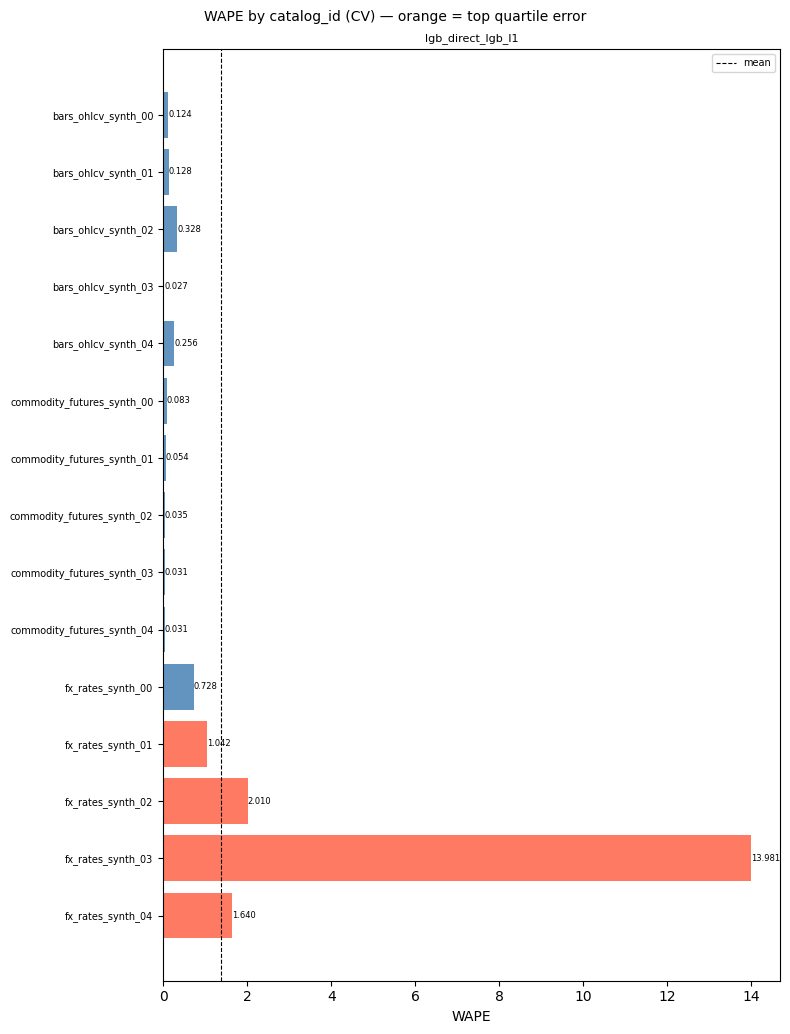

error_by_domain_table.png


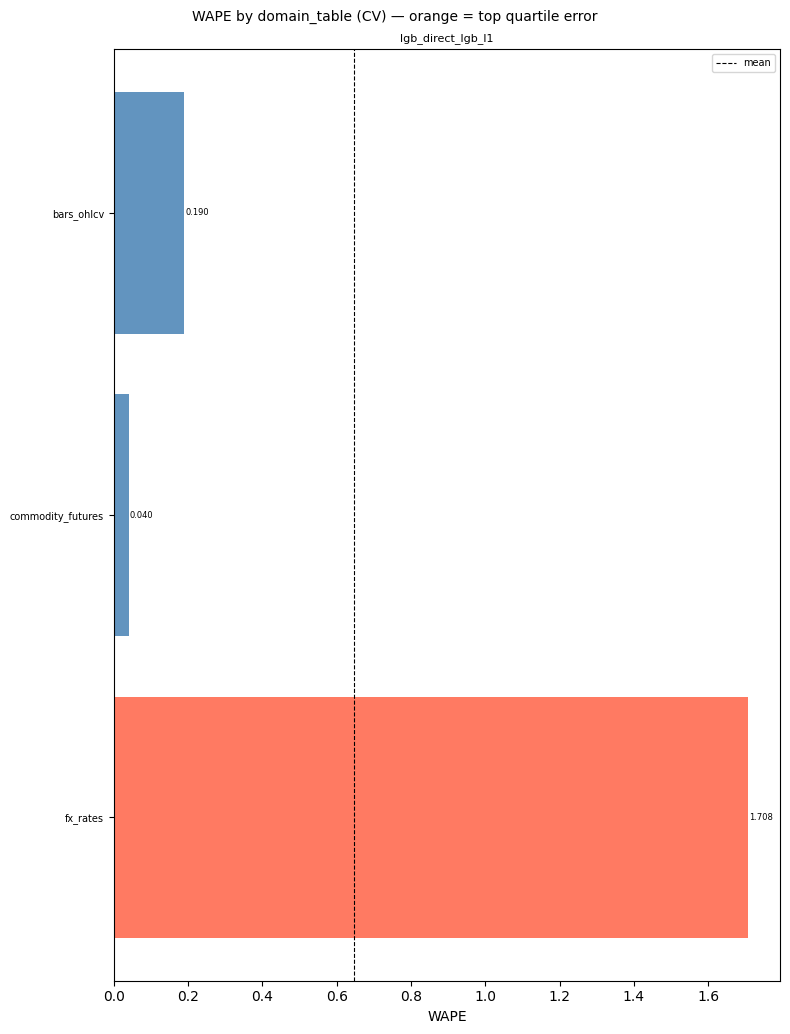

In [11]:
from IPython.display import Image, display

viz_dir = artifacts_dir / "viz"
for name in ["error_by_catalog_id.png", "error_by_domain_table.png"]:
    print(name)
    display(Image(filename=str(viz_dir / name)))

forecast_lgb_direct_lgb_l1.png


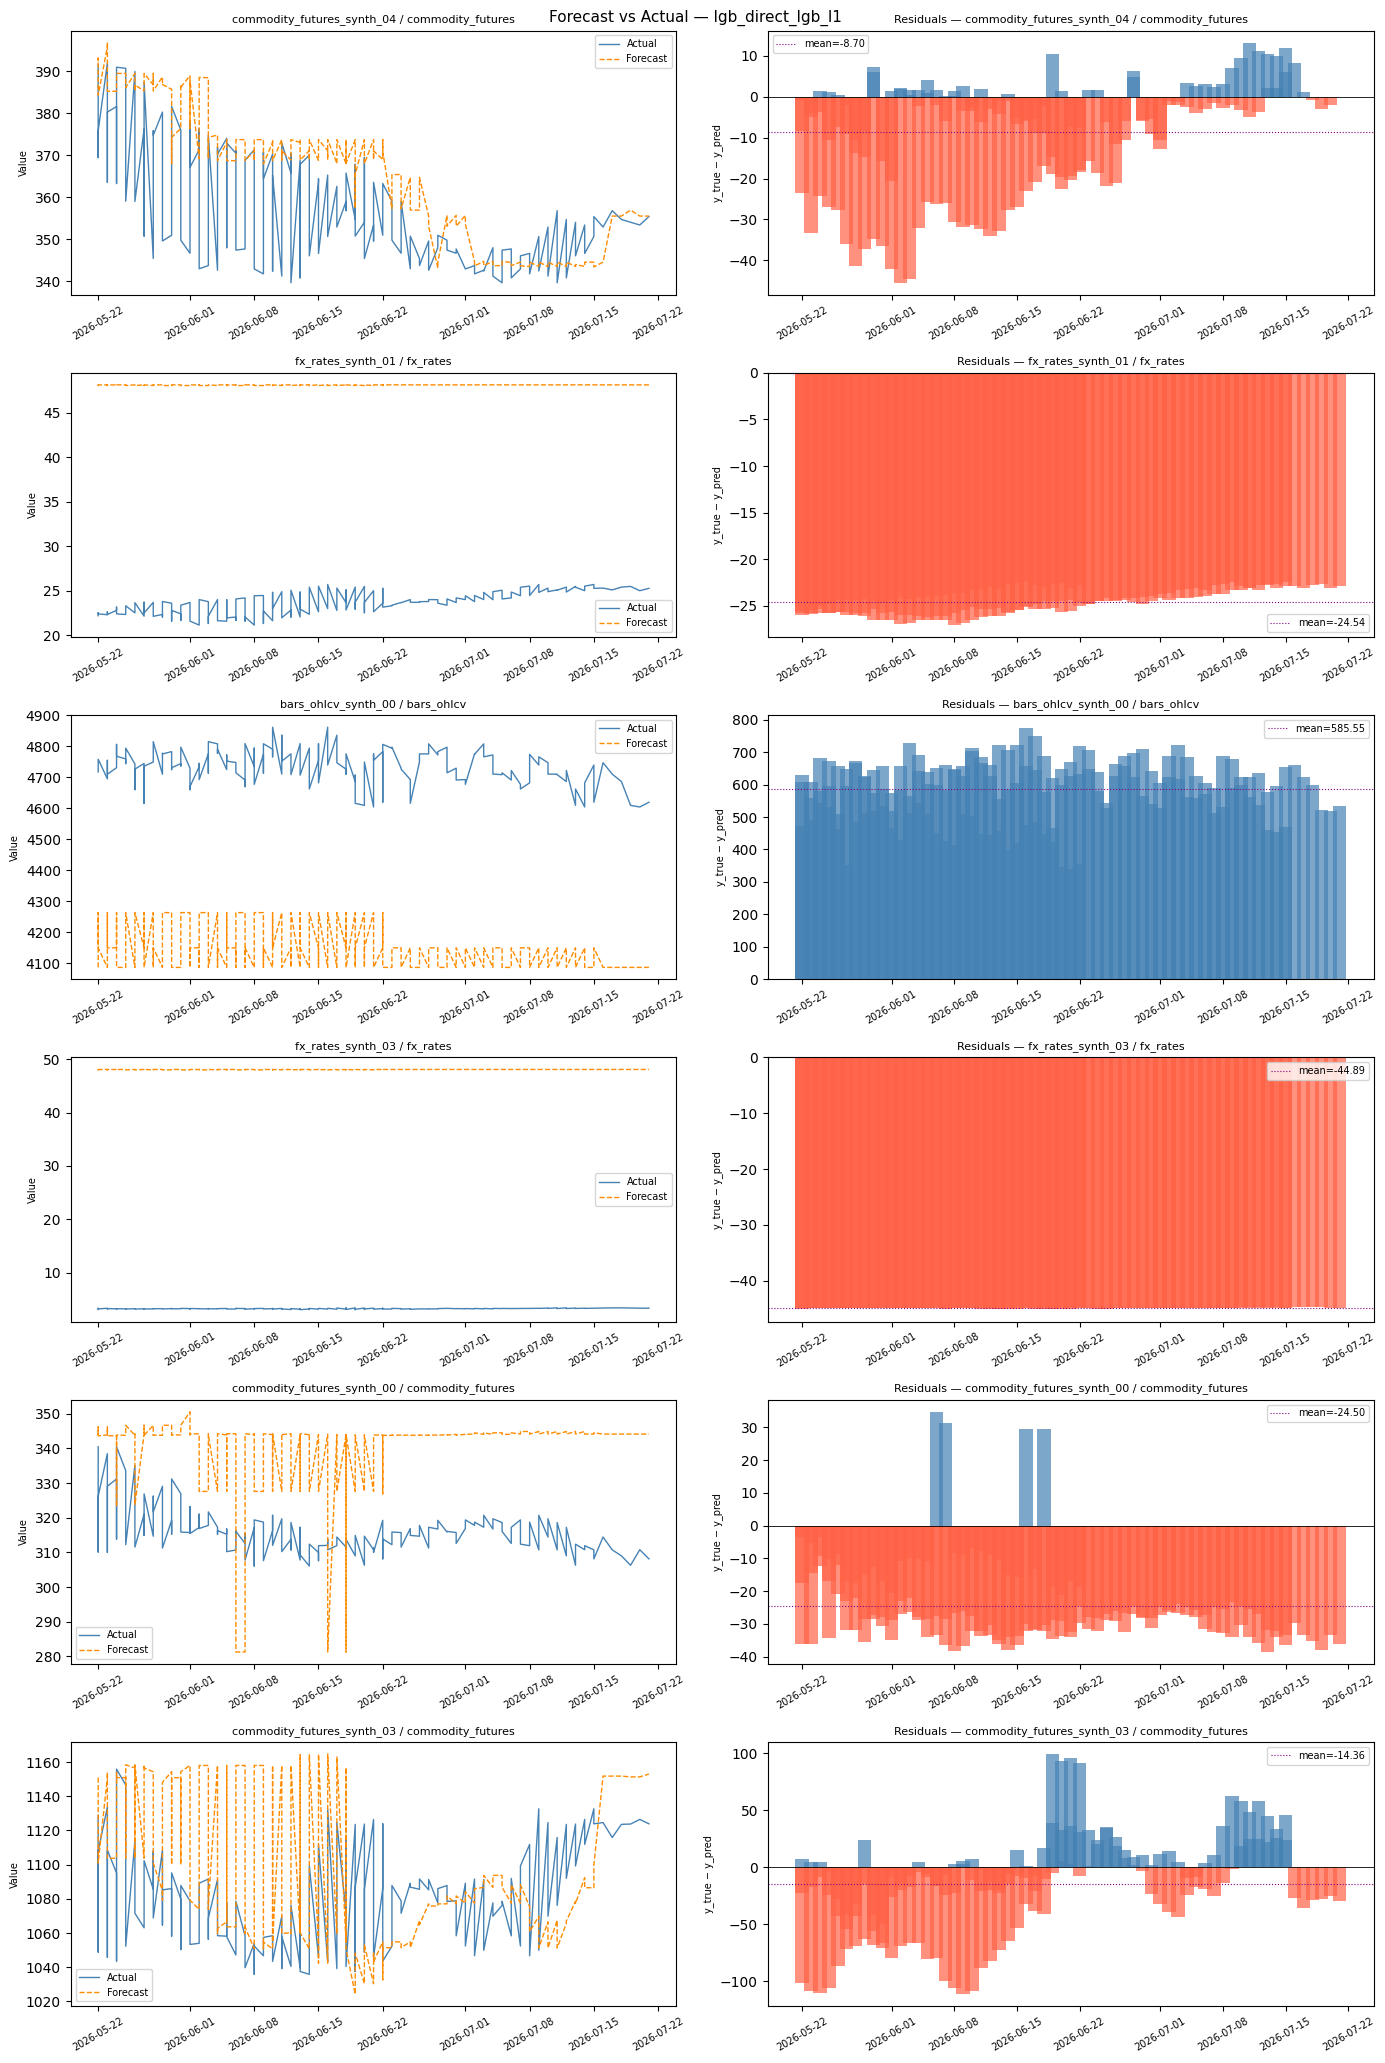

In [12]:
forecast_plots = sorted(viz_dir.glob("forecast_*.png"))
assert forecast_plots, "expected at least one forecast_*.png"
print(forecast_plots[0].name)
display(Image(filename=str(forecast_plots[0])))

## 6. Known limitation: the item x location grain

The engine's grain model (`GrainKeys` in its config schema) is a fixed two-slot
`item` + `location` pair -- every shipped example config uses a true item x location
panel (e.g. `item_id` sold at many `store_id`s). `market_data` assets only have one
natural identifier, `catalog_id`, so this maps `item: catalog_id`, `location:
domain_table`. Each `catalog_id` has exactly one `domain_table` value, so `location`
never varies independently the way it would for a real item x store panel -- an
accepted limitation for this pass, not a defect. The diagnostic plots above still work
because nothing in the engine's CV/feature/leakage logic actually *requires*
`location` to vary per item; it only requires the columns to exist.

## 7. Running this against real BigQuery data later

`forecasting/configs/market_data_assets_bigquery.yaml` is the real, BigQuery-backed
counterpart of the config run above -- identical `dataset`/`horizon`/`models`, with
`data_sources.modeling_base` pointing at `market_data.forecast_assets` instead of the
synthetic parquet. It isn't runnable yet because `market_data` has no real rows (no
ingestion pipeline exists -- tracked in `project_design.md` §9). Once one does:

```bash
cd AIML-ML-Multi-Forecast-Engine
PYTHONIOENCODING=utf-8 uv run horizons run --mode smoke --config /absolute/path/to/forecasting/configs/market_data_assets_bigquery.yaml
```

Everything demonstrated in this notebook -- the view shape, the grain mapping, the
feature pipeline, the diagnostics -- carries over unchanged; only the data source
swaps from synthetic to real.